## Do athletes who compete across multiple event styles really win more Olympic medals?: Women’s freestyle skiing

#### Introduction

Women’s freestyle skiing has become a highly anticipated discipline in the world of Olympic sports and with the ongoing 2026 Winter Olympics we are reminded of the stand-out athletes who are making groundbreaking achievements. And with the presence of so many successful athletes comes the opportunity to look at how individual accomplishments are shaping the competitiveness of free ski. 

A case that we can examine is Eileen Gu who has made significant acheievements and become one of the most decorated athelete's in her sport. She competes across events of Halfpipe, Slopestyle, and Big Air. Her emergence shines a light on how the dynamics and competiveness of free ski are changing. So what does this mean for other athletes when one is so exceptional? Are medals becoming concentrated among versatile multi-event athletes?

And to expand: Does the success of multi-event athletes like Eileen Gu reflect a shift within the sport?”

<img src= "img/eileengu.webp" width=400/>

Photo of Eileen Gu by Abbie Parr.

https://nypost.com/2026/02/22/sports/eileen-gu-wins-gold-in-womens-freeski-halfpipe-defending-winter-olympics-title/

#### Winter Olympics Dataset (DOW #3)

##### Sources
* https://www.olympedia.org/
* https://github.com/KeithGalli/Olympics-Dataset/

##### Datasets

* In the `data` folder:
  1. `winter_olympics_medals.csv` - subset of `results.csv` from https://github.com/KeithGalli/Olympics-Dataset/ for just **Winter Olympics**
  2. `bios.csv` - information about athletes in `results.csv` (both Winter and Summer games)
  3. `bios_locs.csv` - adding geospatial locations for birth place to `bios.csv`
  4. `populations.csv` - population counts for country by year from 1960-2023
  5. `country-and-continent-codes-list.csv` - mapping between 2- and 3-character country codes and names and numbers

---


### Setup

In [16]:
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt

### Load data

wolympics_df = pd.read_csv('data/winter_olympics_medals.csv')
wolympics_df.shape

In [18]:
wolympics_df

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
0,1932.0,Winter,Bobsleigh (Bobsleigh),"Four, Men (Olympic)",Eddie Eagan,8658,USA,United States 1,1.0,False,Gold
1,1948.0,Winter,Winter Pentathlon,"Winter Pentathlon, Men (Olympic (non-medal))",Derek Allhusen,11530,GBR,NaN,6.0,False,NaN
2,1924.0,Winter,Bobsleigh (Bobsleigh),"Four/Five, Men (Olympic)",Charley Stoffel,12796,SUI,Switzerland 2,NaN,False,NaN
3,1928.0,Winter,Bobsleigh (Bobsleigh),"Four/Five, Men (Olympic)",Charley Stoffel,12796,SUI,Switzerland 1,8.0,False,NaN
4,2002.0,Winter,Bobsleigh (Bobsleigh),"Two, Women (Olympic)",Antonella Bellutti,13065,ITA,Gerda Weissensteiner,7.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...
64504,2022.0,Winter,Luge,"Singles, Men (Olympic)",Marián Skupek,148983,SVK,NaN,26.0,False,NaN
64505,2022.0,Winter,Alpine Skiing (Skiing),"Slalom, Women (Olympic)",Elsa Fermbäck,148984,SWE,NaN,28.0,False,NaN
64506,2022.0,Winter,Alpine Skiing (Skiing),"Team, Mixed (Olympic)",Hilma Lövblom,148985,SWE,Sweden,13.0,False,NaN
64507,2022.0,Winter,Alpine Skiing (Skiing),"Giant Slalom, Women (Olympic)",Hilma Lövblom,148985,SWE,NaN,NaN,False,NaN


<img src= "img/DonnaW.png" width=400/>
Photo of Donna Weinbrecht

While there are many disciplines worth examining, freestyle skiing (free ski) is a relatively more new sport within the Olympic games. Free Ski was introduced to the Olympics in 1992 in Albertville, France with Donna Weinbrecht of team USA winning the first gold medal in Women's Free Ski Moguls. Now women can compete across Aerials, Moguls, Ski Cross, Halfpipe, Slopestyle, and Big Air. However, only 16 athletes are currently allowed to compete across all Free Ski events limiting the pool of who can become a victor in multiple styles.

This means that it an even bigger accomplishment to win medals across events as only a few earn that oppurtunity.

In [19]:
wolympics_df.columns

Index(['year', 'type', 'discipline', 'event', 'as', 'athlete_id', 'noc',
       'team', 'place', 'tied', 'medal'],
      dtype='str')

In [20]:
wolympics_df.value_counts('year').to_frame().sort_values('year')

,count
year,
1924.0,551
1928.0,636
1932.0,550
1936.0,977
1948.0,1150
1952.0,1120
1956.0,1349
1960.0,1143
1964.0,1804


This data ranges from 1924, the year of the first Winter Olympics, to 2022 which took place in Beijing, China.

In [21]:
wolympics_df['discipline'].drop_duplicates

<bound method Series.drop_duplicates of 0         Bobsleigh (Bobsleigh)
1             Winter Pentathlon
2         Bobsleigh (Bobsleigh)
3         Bobsleigh (Bobsleigh)
4         Bobsleigh (Bobsleigh)
                  ...          
64504                      Luge
64505    Alpine Skiing (Skiing)
64506    Alpine Skiing (Skiing)
64507    Alpine Skiing (Skiing)
64508                       NaN
Name: discipline, Length: 64509, dtype: str>

In [22]:
freeski_women = wolympics_df[
    (wolympics_df['discipline'].str.contains('Freestyle Skiing', na=False)) &
    (wolympics_df['event'].str.contains('Women', na=False))
]

In [24]:
freeski_women = freeski_women[freeski_women['medal'].notna()]
freeski_women.sort_values('year')

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal
2503,1992.0,Winter,Freestyle Skiing (Skiing),"Moguls, Women (Olympic)",Stine Lise Hattestad,81261,NOR,NaN,3.0,False,Bronze
3471,1992.0,Winter,Freestyle Skiing (Skiing),"Moguls, Women (Olympic)",Yelizaveta Kozhevnikova,81557,EUN,NaN,2.0,False,Silver
7353,1992.0,Winter,Freestyle Skiing (Skiing),"Moguls, Women (Olympic)",Donna Weinbrecht,83021,USA,NaN,1.0,False,Gold
2504,1994.0,Winter,Freestyle Skiing (Skiing),"Moguls, Women (Olympic)",Stine Lise Hattestad,81261,NOR,NaN,1.0,False,Gold
3900,1994.0,Winter,Freestyle Skiing (Skiing),"Aerials, Women (Olympic)",Marie Lindgren,81683,SWE,NaN,2.0,False,Silver
...,...,...,...,...,...,...,...,...,...,...,...
60522,2022.0,Winter,Freestyle Skiing (Skiing),"Big Air, Women (Olympic)",Eileen Gu,139214,CHN,NaN,1.0,False,Gold
60584,2022.0,Winter,Freestyle Skiing (Skiing),"Slopestyle, Women (Olympic)",Kelly Sildaru,139240,EST,NaN,3.0,False,Bronze
62800,2022.0,Winter,Freestyle Skiing (Skiing),"Halfpipe, Women (Olympic)",Rachael Karker,147945,CAN,NaN,3.0,False,Bronze
63519,2022.0,Winter,Freestyle Skiing (Skiing),"Ski Cross, Women (Olympic)",Daniela Maier,148407,GER,NaN,3.0,True,Bronze


We can see all of the results of the Free Ski event from went it was first introduced up until 2022 where Eileen Gu made her Olympic debut, winning gold for China. She intially launched a lot of controversy over her decision to compete for China due to her Chinese-American background and residence in the U.S.

Still, even in the face of online backlash, Gu stuck with her choice in representing her Mother's native country and has now won 6 medals for China.

<img src= "img/eileen-gu-2.webp" width=400/>

Photo by Getty Images

https://www.nytimes.com/athletic/7049798/2026/02/17/eileen-gu-winter-olympics-freestyle-skiing-china-controversy/

In [33]:
freeski_athletes = freeski_women['as'].drop_duplicates().tolist()
freeski_athletes

['Colette Brand',
 'Stine Lise Hattestad',
 'Yelizaveta Kozhevnikova',
 'Hilde Synnøve Lid',
 'Marie Lindgren',
 'Liz McIntyre',
 'Tatjana Mittermayer',
 'Tae Satoya',
 'Nikki Stone',
 'Lina Cheryazova',
 'Kari Traa',
 'Donna Weinbrecht',
 'Xu Nannan',
 'Ala Tsuper',
 'Veronica Brenner',
 'Evelyne Leu',
 'Alisa Camplin',
 'Deidra Dionne',
 'Li Nina',
 'Lydia Lassila',
 'Guo Xinxin',
 'Hedda Berntsen',
 'Shannon Bahrke',
 'Jennifer Heil',
 'Sandra Laoura',
 'Hannah Kearney',
 'Anna Holmlund',
 'Ashleigh McIvor',
 'Chloé Dufour-Lapointe',
 'Fanny Smith',
 'Kelsey Serwa',
 'Marion Josserand',
 'Xu Mengtao',
 'Yuliya Galysheva',
 'Hanna Huskova',
 'Britt Phelan',
 'Justine Dufour-Lapointe',
 'Dara Howell',
 'Kim Lamarre',
 'Marielle Thompson',
 'Zhang Xin',
 'Perrine Laffont',
 'Marie Martinod',
 'Ayana Onozuka',
 'Sandra Näslund',
 'Maddie Bowman',
 'Devin Logan',
 'Brita Sigourney',
 'Jakara Anthony',
 'Cassie Sharpe',
 'Kong Fanyu',
 'Tess Ledeux',
 'Izzy Atkin',
 'Mathilde Gremaud',
 '

In [34]:
medal_counts = freeski_women['as'].value_counts().reset_index(name='medal_total')
medal_counts

,as,medal_total
0,Kari Traa,3
1,Eileen Gu,3
2,Mathilde Gremaud,3
3,Yelizaveta Kozhevnikova,2
4,Stine Lise Hattestad,2
...,...,...
56,Jaelin Kauf,1
57,Kelly Sildaru,1
58,Rachael Karker,1
59,Daniela Maier,1


In [37]:
versatility = (freeski_women.groupby(['year','as'])['event'].nunique().reset_index(name='event_styles'))

versatility.sort_values('event_styles', ascending=False)

,year,as,event_styles
69,2022.0,Eileen Gu,3
76,2022.0,Mathilde Gremaud,2
2,1992.0,Yelizaveta Kozhevnikova,1
1,1992.0,Stine Lise Hattestad,1
4,1994.0,Lina Cheryazova,1
...,...,...,...
75,2022.0,Marielle Thompson,1
77,2022.0,Rachael Karker,1
78,2022.0,Sandra Näslund,1
79,2022.0,Tess Ledeux,1


As represented here, and As of the year 2022, Gu had comepeted in 3 different types of events which is more than all atheletes under the Winter Olympics Free Ski data.

In [38]:
events_and_medals = (freeski_women.groupby('as')['event'].nunique().reset_index(name='event_styles'))

events_and_medals = medal_counts.merge(events_and_medals, on='as')
events_and_medals

,as,medal_total,event_styles
0,Kari Traa,3,1
1,Eileen Gu,3,3
2,Mathilde Gremaud,3,2
3,Yelizaveta Kozhevnikova,2,1
4,Stine Lise Hattestad,2,1
...,...,...,...
56,Jaelin Kauf,1,1
57,Kelly Sildaru,1,1
58,Rachael Karker,1,1
59,Daniela Maier,1,1


In [40]:
avg_medals = events_and_medals.groupby('event_styles')['medal_total'].mean()
avg_medals

event_styles
1    1.322034
2    3.000000
3    3.000000
Name: medal_total, dtype: float64

Here it is shown that on average those who compete in more event styles end up winning more medals with those entered in 2 and 3 events average around 3 medals and those in one event averaging a little over 1.

(However, it makes sense that those who only competed in one event average one medal because we are only looking at athletes who have competed and won wether bronze, silver, or gold and most only ever see one event)

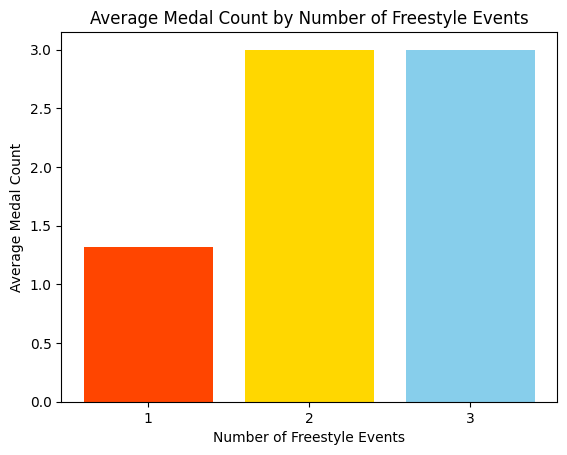

In [158]:
import matplotlib.pyplot as plt

labels = avg_medals.index.astype(str)   
values = avg_medals.values             

plt.bar(labels, values, color=['orangered','gold','skyblue'])

plt.xlabel('Number of Freestyle Events')
plt.ylabel('Average Medal Count')
plt.title('Average Medal Count by Number of Freestyle Events')

plt.show()

While it's insightful to see if the number of events and athlete competes in allows for more medals, we can also ask what events win the most medals overall?

In [42]:
event_counts = freeski_women['event'].value_counts()

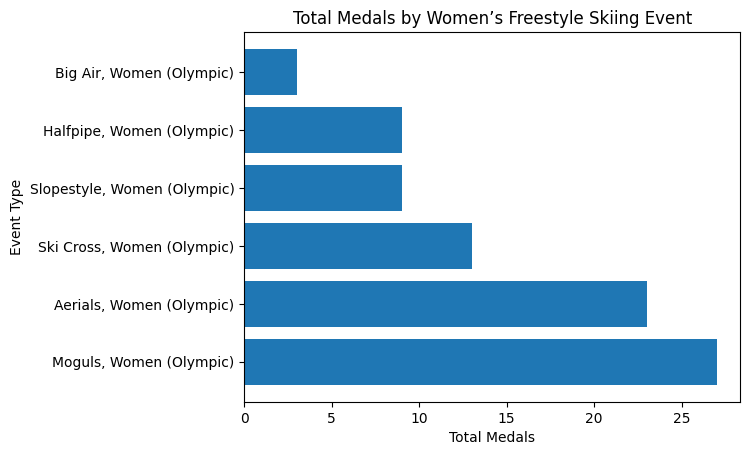

In [43]:
import matplotlib.pyplot as plt

labels = event_counts.index
values = event_counts.values


plt.barh(labels, values)
plt.xlabel('Total Medals')
plt.ylabel('Event Type')
plt.title('Total Medals by Women’s Freestyle Skiing Event')

plt.show()

From the chart it is shown that the event of Moguls has garnered the most medals from 1992 to 2022. This also makes sense as it was the first Free Ski event to enter the Winter Olympics.

### Conclusion

From examining Women's Free Ski and looking to Eileen Gu to help explain the shift in medals won, we can determine that athletes who compete in different event styles do end up with more medals than those who stick to just competing in one event style. It will be interesting and telling to witness how the 16 person rule holds up with break out stars like Eileen Gu and if the Olympics will open up the slopes for more competitors to rise against her. 